In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [15]:
df=pd.read_csv('train.csv')
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


In [16]:
print(df.isnull().sum())

User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            173638
Product_Category_3            383247
Purchase                           0
dtype: int64


In [17]:
df = df.drop(columns=['Product_Category_2', 'Product_Category_3'])
print(df.isnull().sum())

User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category_1            0
Purchase                      0
dtype: int64


In [18]:
print(df.dtypes)

User_ID                       int64
Product_ID                      str
Gender                          str
Age                             str
Occupation                    int64
City_Category                   str
Stay_In_Current_City_Years      str
Marital_Status                int64
Product_Category_1            int64
Purchase                      int64
dtype: object


In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:


print(df.isnull().sum())  
print(df.head())

User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category_1            0
Purchase                      0
dtype: int64
   User_ID Product_ID Gender   Age  Occupation City_Category  \
0  1000001  P00069042      F  0-17          10             A   
1  1000001  P00248942      F  0-17          10             A   
2  1000001  P00087842      F  0-17          10             A   
3  1000001  P00085442      F  0-17          10             A   
4  1000002  P00285442      M   55+          16             C   

  Stay_In_Current_City_Years  Marital_Status  Product_Category_1  Purchase  
0                          2               0                   3      8370  
1                          2               0                   1     15200  
2                          2               0       

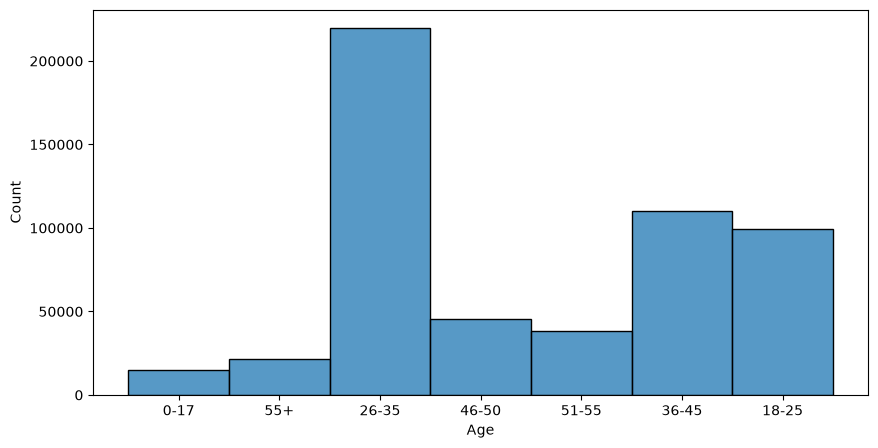

In [21]:
plt.figure(figsize=(10,5))
sns.histplot(df['Age'])
plt.show()

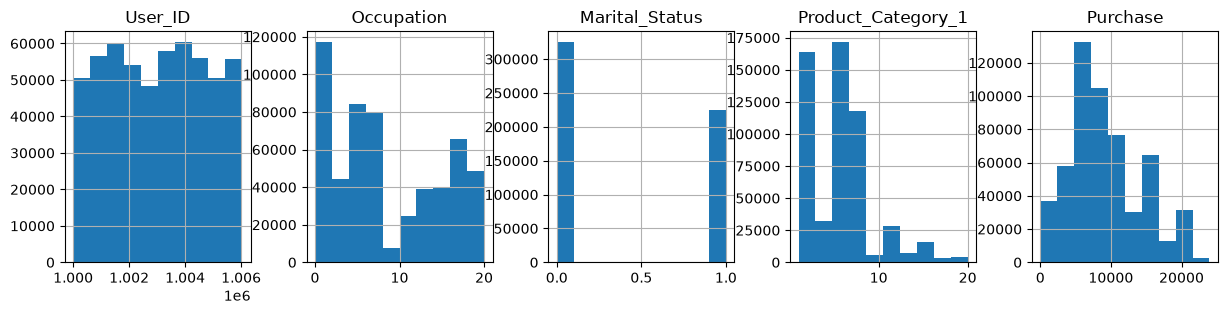

In [27]:
df.hist(layout=(1,6), figsize=(18,3))
plt.show()

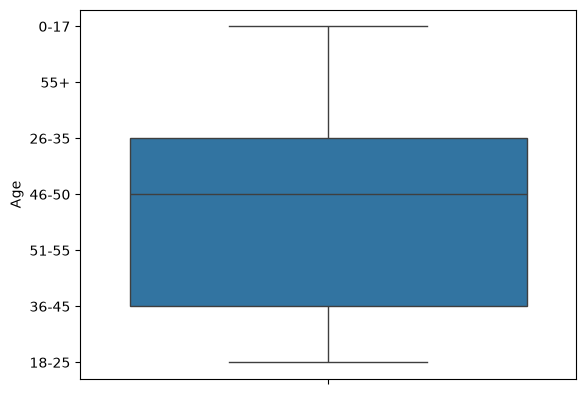

In [29]:
sns.boxplot(data=df, y='Age')
plt.show()

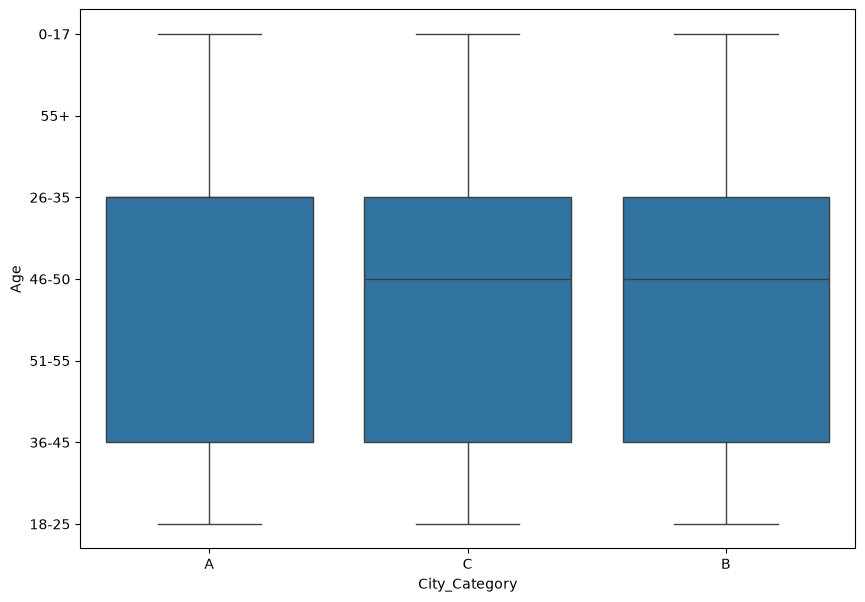

In [32]:
plt.figure(figsize=(10,7))
sns.boxplot(data=df, y='Age', x='City_Category')
plt.show()

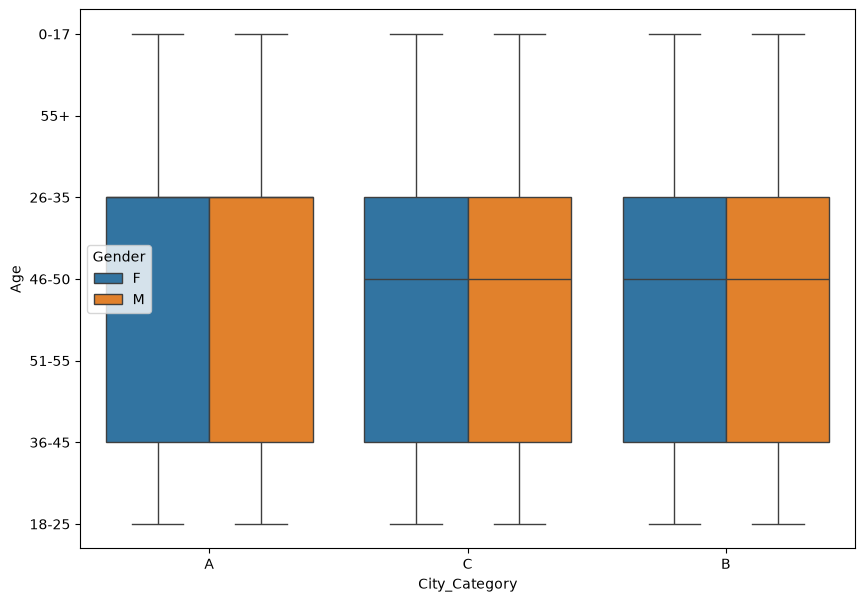

In [33]:
plt.figure(figsize=(10,7))
sns.boxplot(data=df, y='Age', x='City_Category', hue='Gender')
plt.show()

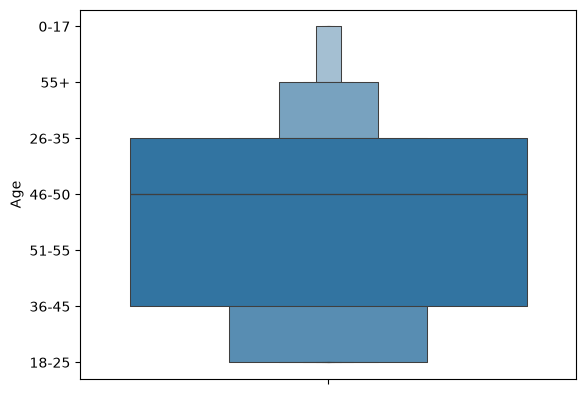

In [35]:
sns.boxenplot(data=df, y='Age')
plt.show()

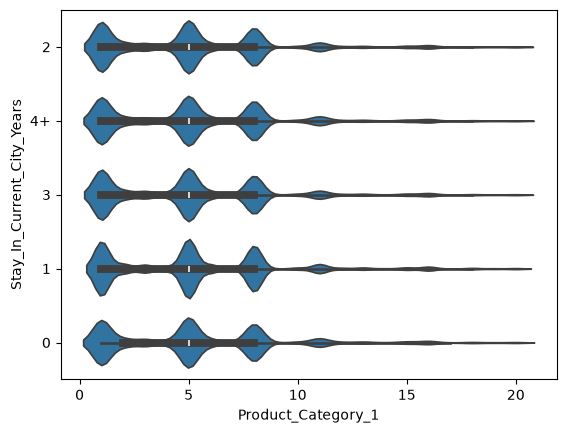

In [37]:
sns.violinplot(data=df,x='Product_Category_1', y='Stay_In_Current_City_Years')
plt.show()

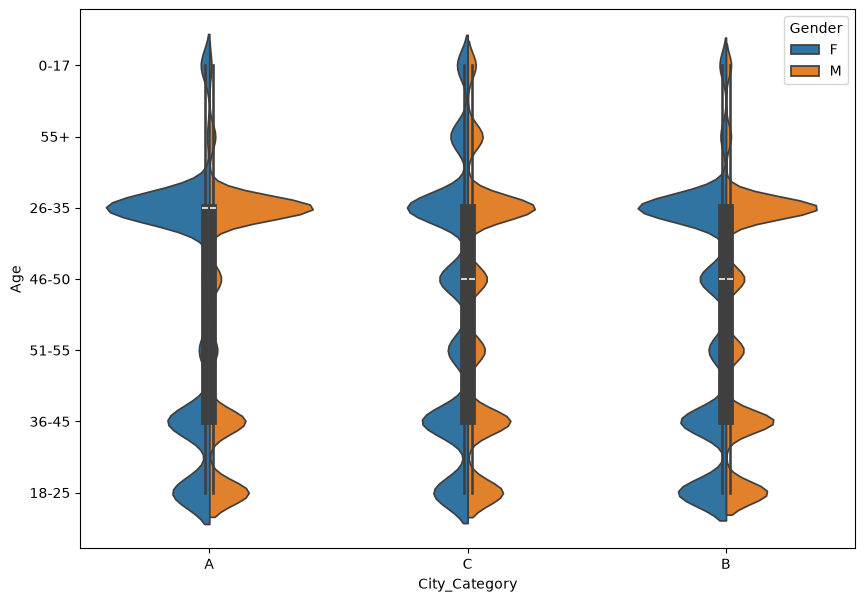

In [38]:
plt.figure(figsize=(10,7))
sns.violinplot(data=df, y='Age', x='City_Category', hue='Gender', split=True)
plt.show()

In [41]:
print(df.columns)

Index(['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category_1',
       'Purchase'],
      dtype='str')


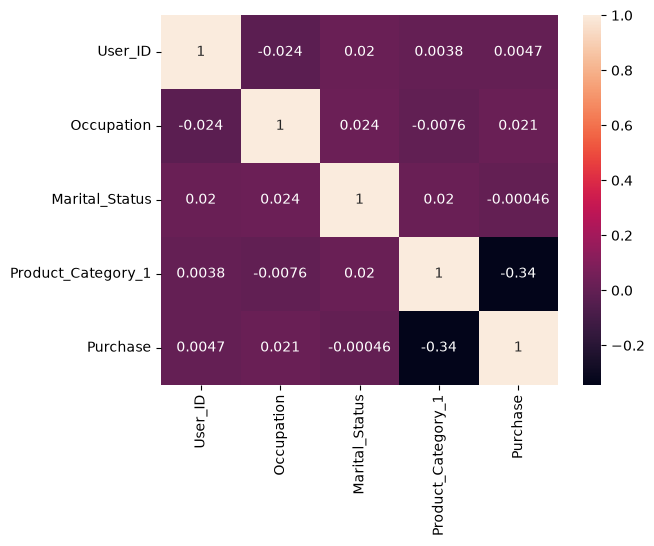

In [44]:
correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(correlation_matrix, annot=True)
plt.show()

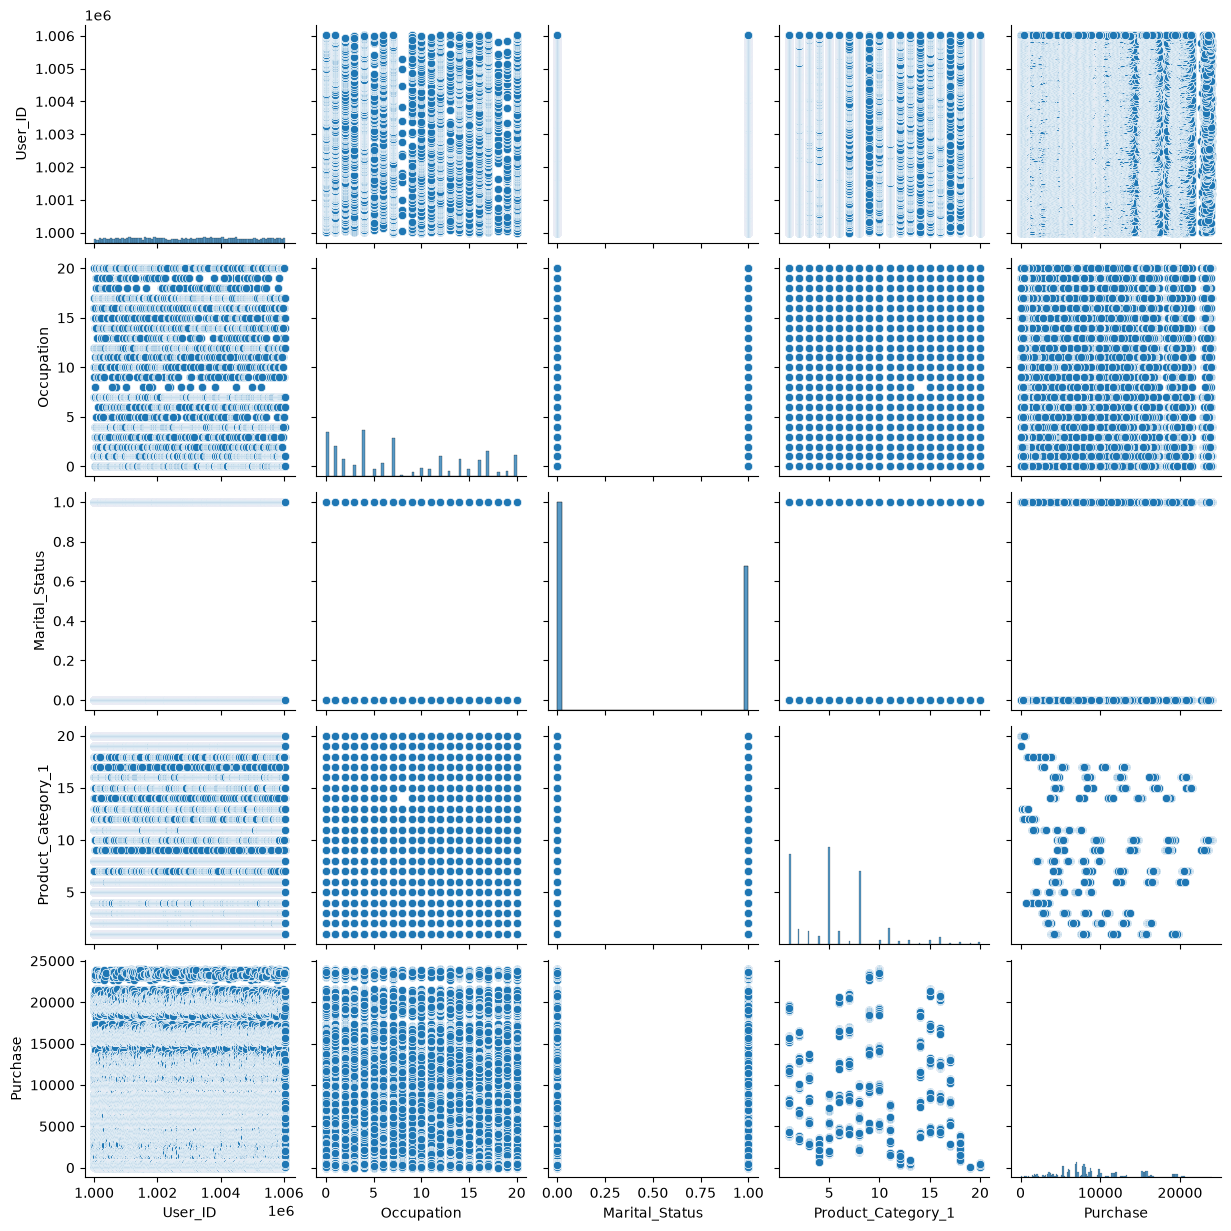

In [42]:
sns.pairplot(df[['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category_1',
       'Purchase']])
plt.show()

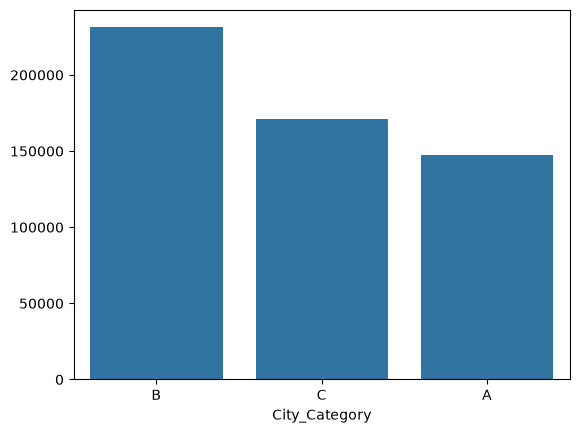

In [45]:
sns.barplot(x=df['City_Category'].value_counts().index,
            y=df['City_Category'].value_counts().values)
plt.show()

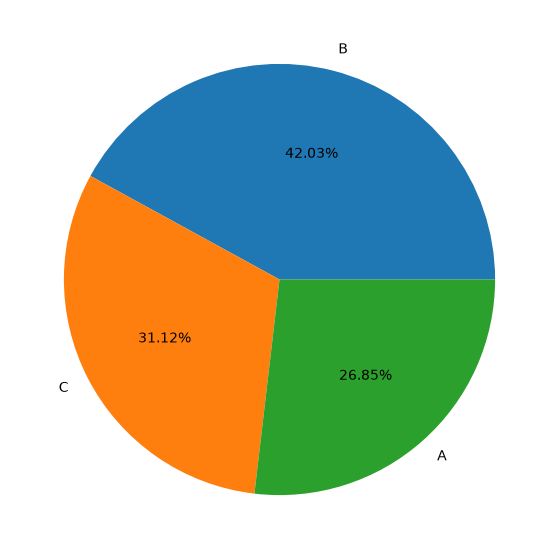

In [46]:
plt.figure(figsize=(10,7))
plt.pie(x=df['City_Category'].value_counts().values,
        labels=df['City_Category'].value_counts().index,
        autopct='%2.2f%%')
plt.show()

In [47]:
pd.crosstab(index=df['Marital_Status'], columns=df['City_Category'])

City_Category,A,B,C
Marital_Status,,,
0,91173,136721,96837
1,56547,94452,74338


c:\Users\yalin\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\axisgrid.py:718: UserWarning: Using the countplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
c:\Users\yalin\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\yalin\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)


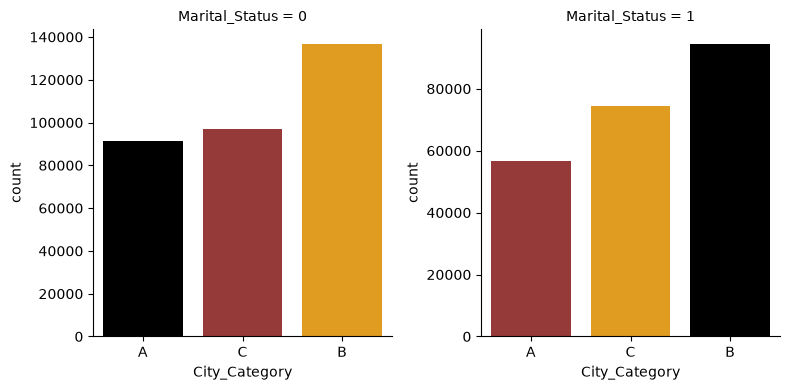

In [49]:
# creating a facet grid with columns as Marital_Status=0 and Marital_Status=1
grid = sns.FacetGrid(data=df, col='Marital_Status', height=4, aspect=1, sharey=False)
# mapping bar plot and the data on to the grid
grid.map(sns.countplot, 'City_Category', palette=['black', 'brown', 'orange'])
plt.show()

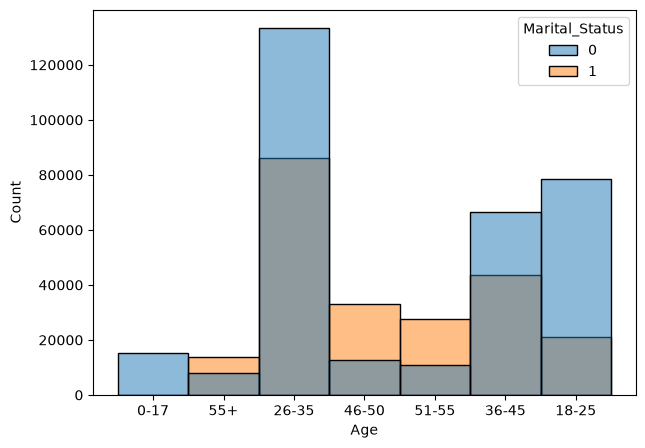

In [51]:
# creating the histogram of 'age'
plt.figure(figsize=(7,5))
sns.histplot(data=df, x='Age', bins=16, hue='Marital_Status')
plt.show()